# Z24 — split nghiêm ngặt và train-only augmentation

Notebook này dựng lại toàn bộ bản ghi thành dữ liệu `(918, 27, 10000)`, giữ nguyên 10000 điểm và 27 kênh. Không crop, không downsample.

Mức khó được chọn là **Hard (unseen setup)**:

- Train: setup 0–5.
- Validation: setup 6.
- Test: setup 7–8.
- Chỉ train được augmentation; validation và test luôn sạch.
- Augmentation mô phỏng sai khác cảm biến nhưng không thay đổi độ dài hoặc tần số lấy mẫu.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.signal import welch
from tsaug import AddNoise, Drift, Dropout

DATA_DIR = Path("Z24-dataset-processed")
FS = 100.0  # giả định để vẽ trục thời gian/tần số; dataset card chưa xác nhận
SEED = 42

X_source = np.load(DATA_DIR / "inputs.npy", mmap_mode="r")
y_source = np.load(DATA_DIR / "labels.npy").astype(np.int64)

print("Dữ liệu nguồn:", X_source.shape, X_source.dtype)
print("Nhãn nguồn:", y_source.shape, np.unique(y_source))

Dữ liệu nguồn: (1530, 27, 6000) float32
Nhãn nguồn: (1530,) [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]


## 1. Dựng dữ liệu 10000 điểm không làm mất dữ liệu

```text
(17, 9, 10, 27, 6000) → (17, 9, 6, 27, 10000) → (918, 27, 10000)
```

Mỗi mẫu có đúng một nhãn trong `y_10k`; mỗi lớp có `9 × 6 = 54` mẫu. File gần 1 GB chỉ được tạo nếu chưa tồn tại.

In [2]:
N_SCENARIOS, N_SETUPS, N_CHANNELS = 17, 9, 27
OLD_WINDOWS, OLD_LEN = 10, 6000
NEW_WINDOWS, NEW_LEN = 6, 10000
input_10k_path = DATA_DIR / "inputs_10000.npy"

assert X_source.shape == (N_SCENARIOS * N_SETUPS * OLD_WINDOWS, N_CHANNELS, OLD_LEN)
assert OLD_WINDOWS * OLD_LEN == NEW_WINDOWS * NEW_LEN
source_5d = X_source.reshape(N_SCENARIOS, N_SETUPS, OLD_WINDOWS, N_CHANNELS, OLD_LEN)
source_labels = y_source.reshape(N_SCENARIOS, N_SETUPS, OLD_WINDOWS)
assert np.all(source_labels == source_labels[:, :, :1])

if not input_10k_path.exists():
    output = np.lib.format.open_memmap(
        input_10k_path, mode="w+", dtype=X_source.dtype,
        shape=(N_SCENARIOS * N_SETUPS * NEW_WINDOWS, N_CHANNELS, NEW_LEN),
    )
    for scenario_id in range(N_SCENARIOS):
        for setup_id in range(N_SETUPS):
            recording = (source_5d[scenario_id, setup_id]
                         .transpose(1, 0, 2).reshape(N_CHANNELS, 60000))
            first = (scenario_id * N_SETUPS + setup_id) * NEW_WINDOWS
            output[first:first + NEW_WINDOWS] = (
                recording.reshape(N_CHANNELS, NEW_WINDOWS, NEW_LEN).transpose(1, 0, 2)
            )
    output.flush()
    del output

X_10k = np.load(input_10k_path, mmap_mode="r")
y_10k = np.repeat(source_labels[:, :, 0, None], NEW_WINDOWS, axis=2).reshape(-1)
setup_10k = np.broadcast_to(
    np.arange(N_SETUPS)[None, :, None], (N_SCENARIOS, N_SETUPS, NEW_WINDOWS)
).reshape(-1)
window_10k = np.broadcast_to(
    np.arange(NEW_WINDOWS)[None, None, :], (N_SCENARIOS, N_SETUPS, NEW_WINDOWS)
).reshape(-1)
group_10k = np.repeat(np.arange(N_SCENARIOS * N_SETUPS), NEW_WINDOWS)

assert X_10k.shape == (918, 27, 10000)
assert X_source.size == X_10k.size
assert np.array_equal(np.bincount(y_10k), np.full(17, 54))
print("Dữ liệu model:", X_10k.shape, X_10k.dtype)
print("Nhãn model:", y_10k.shape)
print("Số mẫu mỗi lớp:", np.bincount(y_10k))

Dữ liệu model: (918, 27, 10000) float32
Nhãn model: (918,)
Số mẫu mỗi lớp: [54 54 54 54 54 54 54 54 54 54 54 54 54 54 54 54 54]


## 2. Chia train / validation / test theo setup

Đây là split mức khó: model được đánh giá trên các setup đo chưa từng xuất hiện trong train. Sáu cửa sổ thuộc cùng một `(scenario, setup)` luôn nằm cùng một tập, nên không có rò rỉ bản ghi.

In [3]:
train_idx = np.where(setup_10k <= 5)[0]
val_idx = np.where(setup_10k == 6)[0]
test_idx = np.where(setup_10k >= 7)[0]
SPLITS = {"train": train_idx, "validation": val_idx, "test": test_idx}

all_idx = np.concatenate(list(SPLITS.values()))
assert len(np.unique(all_idx)) == len(y_10k)
assert set(group_10k[train_idx]).isdisjoint(group_10k[val_idx])
assert set(group_10k[train_idx]).isdisjoint(group_10k[test_idx])
assert set(group_10k[val_idx]).isdisjoint(group_10k[test_idx])
assert all(np.unique(y_10k[idx]).size == 17 for idx in SPLITS.values())

for name, idx in SPLITS.items():
    print(f"{name:10s}: {len(idx):3d} samples | setups {np.unique(setup_10k[idx])} | "
          f"per-class {np.unique(np.bincount(y_10k[idx]))}")

train     : 612 samples | setups [0 1 2 3 4 5] | per-class [36]
validation: 102 samples | setups [6] | per-class [6]
test      : 204 samples | setups [7 8] | per-class [12]


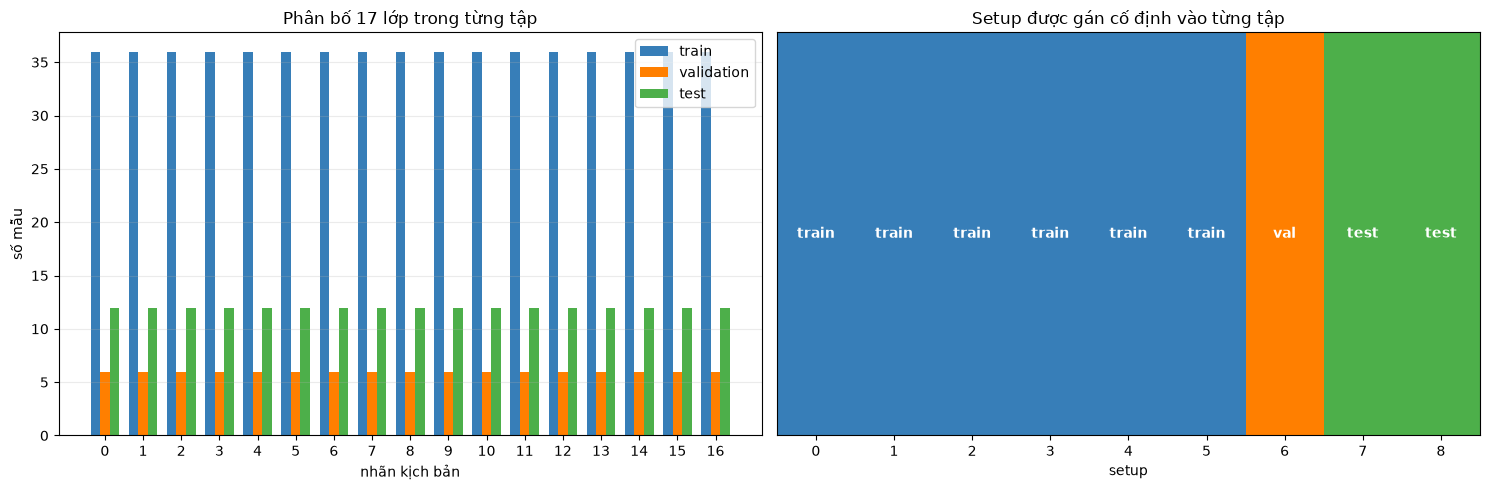

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
split_colors = {"train": "#377eb8", "validation": "#ff7f00", "test": "#4daf4a"}
x = np.arange(N_SCENARIOS)
width = 0.25
for offset, (name, idx) in enumerate(SPLITS.items()):
    counts = np.bincount(y_10k[idx], minlength=N_SCENARIOS)
    axes[0].bar(x + (offset - 1) * width, counts, width, label=name, color=split_colors[name])
axes[0].set(title="Phân bố 17 lớp trong từng tập", xlabel="nhãn kịch bản", ylabel="số mẫu",
            xticks=x)
axes[0].legend()
axes[0].grid(axis="y", alpha=0.25)

setup_assignment = np.array([[0] * 6 + [1] + [2] * 2])
cmap = ListedColormap([split_colors["train"], split_colors["validation"], split_colors["test"]])
axes[1].imshow(setup_assignment, aspect="auto", cmap=cmap, vmin=0, vmax=2)
axes[1].set(title="Setup được gán cố định vào từng tập", xlabel="setup", yticks=[], xticks=np.arange(9))
for s, code in enumerate(setup_assignment[0]):
    axes[1].text(s, 0, ["train", "val", "test"][code], ha="center", va="center",
                 color="white", fontweight="bold")
fig.tight_layout()

## 3. Robust normalization và augmentation chỉ trên train

Thống kê chuẩn hóa chỉ được tính từ train. Pipeline augmentation giữ nguyên shape `(27, 10000)` và gồm:

- 20% mẫu train được giữ sạch làm điểm neo.
- Gaussian noise cộng nhẹ.
- Multiplicative noise nhẹ.
- Baseline drift nhẹ.
- Temporal dropout ngắn, đồng bộ trên các kênh.
- Gain riêng cho từng cảm biến.
- Circular time shift, không cắt hoặc nội suy.
- Channel dropout tối đa 3/27 cảm biến.

Validation và test chỉ được normalize bằng thống kê train, tuyệt đối không augmentation.

In [5]:
# Tính theo từng kênh để giới hạn bộ nhớ tạm khi đọc memmap.
train_center = np.empty((1, N_CHANNELS, 1), dtype=np.float32)
train_scale = np.empty((1, N_CHANNELS, 1), dtype=np.float32)
for channel in range(N_CHANNELS):
    channel_data = np.asarray(X_10k[train_idx, channel, :])
    train_center[0, channel, 0] = np.median(channel_data)
    train_scale[0, channel, 0] = np.median(channel_data.std(axis=1)) + 1e-8

def normalize_batch(x):
    x = (np.asarray(x, dtype=np.float32) - train_center) / train_scale
    return np.clip(x, -10.0, 10.0)

def make_tsaug(seed):
    # tsaug nhận (batch, time, channels); mọi transform đều giữ nguyên độ dài.
    return (
        AddNoise(scale=(0.01, 0.06), kind="additive", normalize=False,
                 per_channel=True, seed=seed) @ 0.70
        + AddNoise(scale=(0.01, 0.04), kind="multiplicative", normalize=False,
                   per_channel=True, seed=seed + 1) @ 0.45
        + Drift(max_drift=(0.01, 0.04), n_drift_points=[2, 3, 4], kind="additive",
                normalize=False, per_channel=True, seed=seed + 2) @ 0.30
        + Dropout(p=(0.005, 0.02), size=(20, 200), fill=0.0,
                  per_channel=False, seed=seed + 3) @ 0.35
    )

def augment_train_batch(x, seed=None, clean_probability=0.20):
    """Augment normalized train samples; shape stays (B, C, T)."""
    rng = np.random.default_rng(seed)
    out = np.array(x, dtype=np.float32, copy=True)
    selected = np.where(rng.random(len(out)) >= clean_probability)[0]
    if not len(selected):
        return out

    work = out[selected]
    aug_seed = int(rng.integers(0, 2**31 - 10))
    work = make_tsaug(aug_seed).augment(work.transpose(0, 2, 1)).transpose(0, 2, 1)

    # Sensor gain: cùng một hệ số trên toàn trục thời gian của mỗi kênh.
    gain_mask = rng.random((len(work), 1, 1)) < 0.70
    gains = rng.uniform(0.85, 1.15, size=(len(work), N_CHANNELS, 1))
    work *= np.where(gain_mask, gains, 1.0)

    # Circular shift giữ đủ 10000 điểm, không crop và không resample.
    for i in range(len(work)):
        if rng.random() < 0.50:
            work[i] = np.roll(work[i], int(rng.integers(-1000, 1001)), axis=-1)

        # Bỏ tối đa 3 cảm biến; zero là median sau robust normalization.
        if rng.random() < 0.35:
            n_drop = int(rng.integers(1, 4))
            dropped = rng.choice(N_CHANNELS, size=n_drop, replace=False)
            work[i, dropped] = 0.0

    out[selected] = np.clip(work, -10.0, 10.0).astype(np.float32)
    return out

def load_split_batch(split, indices, augment=False, seed=None):
    """Load by positions inside a split. Augmentation is forbidden outside train."""
    if augment and split != "train":
        raise ValueError("Augmentation is allowed only for the train split")
    source_ids = SPLITS[split][np.asarray(indices)]
    x = normalize_batch(X_10k[source_ids])
    if augment:
        x = augment_train_batch(x, seed=seed)
    return x, y_10k[source_ids], source_ids

print("train center/scale:", train_center.shape, train_scale.shape)

train center/scale: (1, 27, 1) (1, 27, 1)


## 4. Visualize augmentation

Ba mẫu train thuộc các lớp 0, 8 và 16 được augment với seed cố định để hình có thể tái lập. Các biểu đồ kiểm tra cả miền thời gian, sai khác augmentation và mật độ phổ công suất.

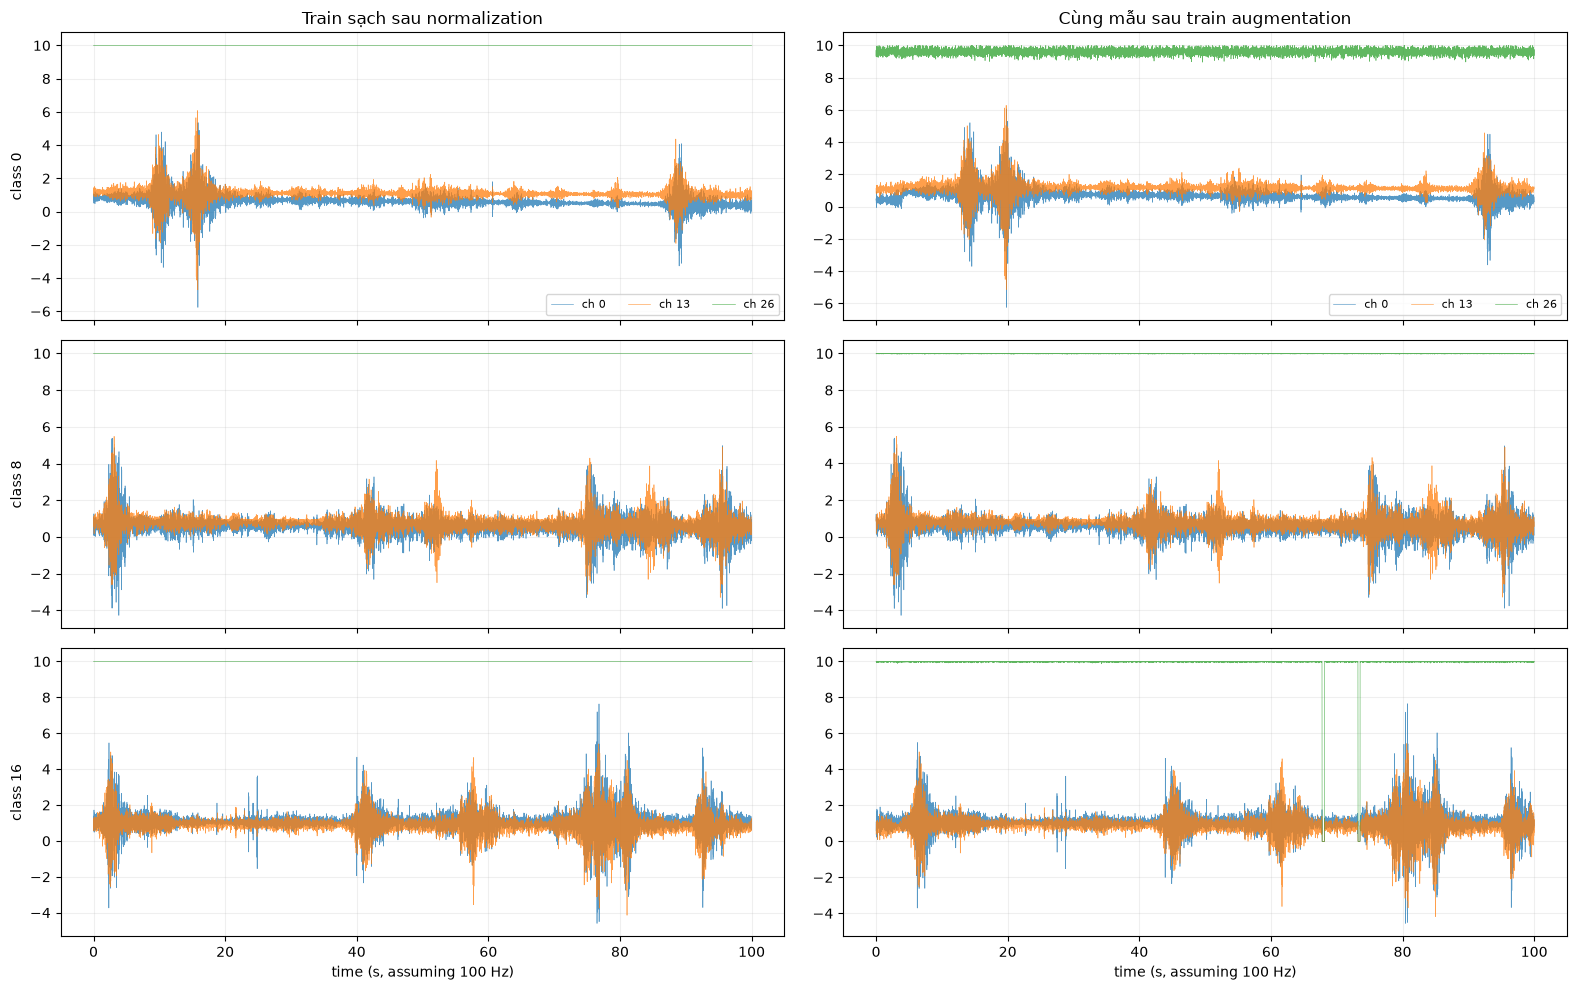

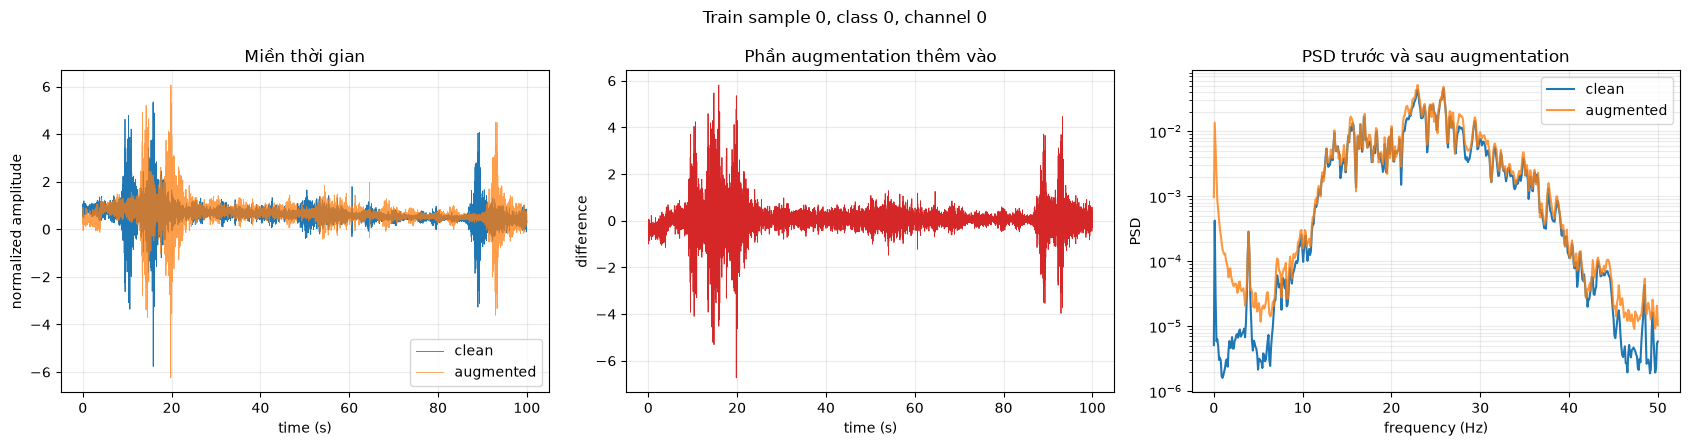

In [6]:
chosen_labels = [0, 8, 16]
chosen_positions = [np.where(y_10k[train_idx] == label)[0][0] for label in chosen_labels]
x_clean, y_demo, source_ids = load_split_batch("train", chosen_positions, augment=False)
x_aug = augment_train_batch(x_clean, seed=SEED, clean_probability=0.0)

channels_to_show = [0, 13, 26]
t = np.arange(NEW_LEN) / FS
fig, axes = plt.subplots(len(chosen_labels), 2, figsize=(16, 10), sharex=True)
for row, label in enumerate(chosen_labels):
    for channel in channels_to_show:
        axes[row, 0].plot(t, x_clean[row, channel], lw=0.45, alpha=0.75, label=f"ch {channel}")
        axes[row, 1].plot(t, x_aug[row, channel], lw=0.45, alpha=0.75, label=f"ch {channel}")
    axes[row, 0].set_ylabel(f"class {label}")
    axes[row, 0].grid(alpha=0.2)
    axes[row, 1].grid(alpha=0.2)
axes[0, 0].set_title("Train sạch sau normalization")
axes[0, 1].set_title("Cùng mẫu sau train augmentation")
axes[0, 0].legend(ncol=3, fontsize=8)
axes[0, 1].legend(ncol=3, fontsize=8)
axes[-1, 0].set_xlabel("time (s, assuming 100 Hz)")
axes[-1, 1].set_xlabel("time (s, assuming 100 Hz)")
fig.tight_layout()

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
demo_row, demo_channel = 0, 0
axes[0].plot(t, x_clean[demo_row, demo_channel], lw=0.6, label="clean")
axes[0].plot(t, x_aug[demo_row, demo_channel], lw=0.6, alpha=0.75, label="augmented")
axes[0].set(title="Miền thời gian", xlabel="time (s)", ylabel="normalized amplitude")
axes[0].legend()
axes[0].grid(alpha=0.25)

difference = x_aug[demo_row, demo_channel] - x_clean[demo_row, demo_channel]
axes[1].plot(t, difference, lw=0.6, color="tab:red")
axes[1].set(title="Phần augmentation thêm vào", xlabel="time (s)", ylabel="difference")
axes[1].grid(alpha=0.25)

f_clean, p_clean = welch(x_clean[demo_row, demo_channel], fs=FS, nperseg=1024)
f_aug, p_aug = welch(x_aug[demo_row, demo_channel], fs=FS, nperseg=1024)
axes[2].semilogy(f_clean, p_clean, label="clean")
axes[2].semilogy(f_aug, p_aug, label="augmented", alpha=0.8)
axes[2].set(title="PSD trước và sau augmentation", xlabel="frequency (Hz)", ylabel="PSD")
axes[2].legend()
axes[2].grid(alpha=0.25, which="both")
fig.suptitle(f"Train sample {source_ids[demo_row]}, class {y_demo[demo_row]}, channel {demo_channel}")
fig.tight_layout()

In [7]:
# Chứng minh validation/test không bị augment và mọi shape vẫn giữ 10000 điểm.
x_train_clean, y_train_demo, _ = load_split_batch("train", [0, 1], augment=False)
x_train_aug, _, _ = load_split_batch("train", [0, 1], augment=True, seed=SEED)
x_val, y_val_demo, _ = load_split_batch("validation", [0, 1], augment=False)
x_test, y_test_demo, _ = load_split_batch("test", [0, 1], augment=False)

assert x_train_clean.shape == x_train_aug.shape == x_val.shape == x_test.shape == (2, 27, 10000)
assert not np.array_equal(x_train_clean, x_train_aug)
try:
    load_split_batch("validation", [0], augment=True)
    raise AssertionError("Validation augmentation guard failed")
except ValueError:
    pass

print("Train clean:", x_train_clean.shape, "| Train augmented:", x_train_aug.shape)
print("Validation clean:", x_val.shape, "| Test clean:", x_test.shape)
print("Augmentation guard: OK — chỉ train được augment")

Train clean: (2, 27, 10000) | Train augmented: (2, 27, 10000)
Validation clean: (2, 27, 10000) | Test clean: (2, 27, 10000)
Augmentation guard: OK — chỉ train được augment


## 5. Cách dùng khi train

Trong mỗi lần `Dataset.__getitem__` hoặc mỗi batch của epoch, lấy train với `augment=True` để tạo biến thể mới. Validation/test luôn gọi `augment=False`:

```python
x_train, y_train, _ = load_split_batch("train", batch_positions, augment=True)
x_val, y_val, _ = load_split_batch("validation", val_positions, augment=False)
x_test, y_test, _ = load_split_batch("test", test_positions, augment=False)
```

Không lưu một bản augmented cố định: augmentation nên chạy on-the-fly để mỗi epoch nhìn thấy một biến thể khác nhau.